### 02. Polynomial Regression

We can't use linear regression directly on non-linear data, before using the non linear data on linear regression we need to do some preprocessing technique called "polynomial feature" by using the prefered degree.

Using the polynomial feature we can fit the line on non-linear data and achieve polynomial regression

In [1]:
import pandas as pd

In [2]:
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv("icecream.csv")

In [4]:
df.corr()

,Temperature (°C),Ice Cream Sales (units)
Temperature (°C),1.000000,-0.175184
Ice Cream Sales (units),-0.175184,1.000000


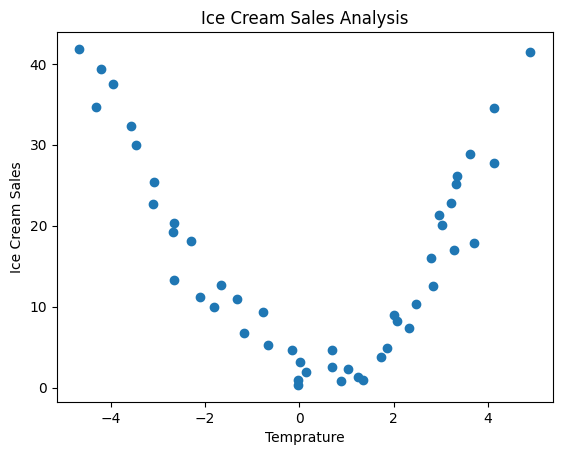

In [5]:
plt.scatter(df['Temperature (°C)'],df['Ice Cream Sales (units)'])
plt.xlabel('Temprature')
plt.ylabel('Ice Cream Sales')
plt.title("Ice Cream Sales Analysis")
plt.show()

In [6]:
from sklearn.preprocessing import PolynomialFeatures

Polynomial Features : It is a preprocessing technique which is used only on feature column not on target column

In [7]:
poly=PolynomialFeatures(degree=3)

#fit_transform(Xtrain)
#|
#|       |----->  Assigning the values to newly created features
#|------> creating new the features based on the degree

#transform(Xtest)

#Transform the Xtest according to the Xtrain (degree)

We use the degree parameter to make linear regression understand the patterns

degree=1  ------> mx+c   #linear regression

degree=2  ------> mx+mx^2+c

degree=3  ------> mx+mx^2+mx^3+c

In [8]:
x=df[['Temperature (°C)']]
y=df[['Ice Cream Sales (units)']]

In [9]:
from sklearn.model_selection import train_test_split

In [10]:
Xtrain,Xtest,Ytrain,Ytest=train_test_split(x,y,test_size=0.2,random_state=42)

In [11]:
Xtrain_Transformed=poly.fit_transform(Xtrain)
Xtrin_test=poly.transform(Xtest)

In [12]:
from sklearn.linear_model import LinearRegression

In [13]:
model=LinearRegression()

In [14]:
model.fit(Xtrain_Transformed,Ytrain)

LinearRegression()

In [15]:
YpredTest=model.predict(Xtrin_test)

In [16]:
YpredTrain=model.predict(Xtrain_Transformed)

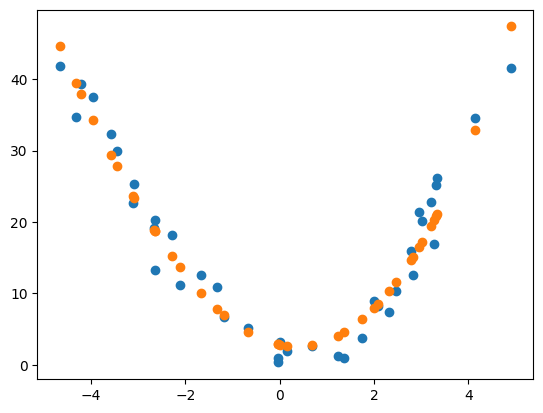

In [17]:
plt.scatter(Xtrain_Transformed[:,1],Ytrain)
plt.scatter(Xtrain_Transformed[:,1],YpredTrain)

In [18]:
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error,root_mean_squared_error

In [19]:
#trainscore
train_score=r2_score(Ytrain,YpredTrain)
print(f"Train Score : {train_score}")

Train Score : 0.9469116778215552


In [20]:
#testscore
test_score=r2_score(Ytest,YpredTest)
print(f"Test Score : {test_score}")

Test Score : 0.8405107685716915


In [21]:
mean_absolute_error(Ytest,YpredTest)

3.228121129776889

In [22]:
root_mean_squared_error(Ytest,YpredTest)

3.888445634341502

In [23]:
mean_squared_error(Ytest,YpredTest)

15.120009451229484

#### Evaluation metrics comparision for different degree values(2 and 3)

Degree=2

Train Score(R^2) :     0.9413665676490518

Test Score (R^2) :     0.843055137193884

MAE :                  3.2299819836597274

RMSE :                 3.857304297171988

MSE:                   14.878796440981484

Degree=3

Train Score(R^2) :     0.9469116778215552

Test Score (R^2) :     0.8405107685716915

MAE :                  3.228121129776889

RMSE :                 3.888445634341502

MSE:                   15.120009451229484